In [1]:
from data_generation import Environment
from eswm import ESWM,get_batch,OpenWorld,accuracy,RandomWall
import torch

In [2]:
open_arena = Environment()
random_wall= Environment(side_length=4,add_wall=True,hidden=5,possible_states=37)

In [3]:
open_embed = OpenWorld()
random_embed = RandomWall()

In [116]:
model=ESWM(open_embed,num_layers=8)
state_dict = torch.load('tester3.pth', map_location='cpu', weights_only=True)
model.load_state_dict(state_dict)
x,y,query_mask,padding_mask = get_batch(open_arena,batch_size=1000,test=True)
model.to(torch.device('cpu'))
model.eval()
output= model(x,padding_mask,query_mask)

m = [query_mask[:, 0:6], query_mask[:, 6:7].repeat(1,6), query_mask[:, 7:]]
p = [torch.masked_select(output[i], m[i]).view(-1,6) for i in range(3)]
t = [torch.masked_select(y[i], m[i][:,:y[i].shape[1]]).view(-1,y[i].shape[1]) for i in range(3)]

acc = accuracy(p,t)


In [158]:
print(acc)

[tensor(0.7797), tensor(0.9588), tensor(0.7937), tensor(6.6016)]


In [118]:
print(accuracy(output,y))

[tensor(0.9240), tensor(0.9860), tensor(0.9330), tensor(22.2109)]


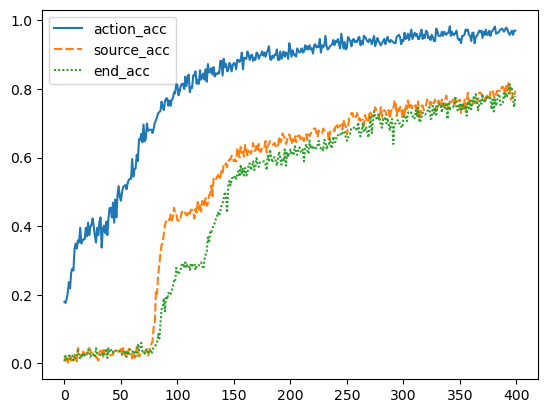

In [157]:
import pandas as pd
import seaborn as sns

data = pd.read_csv('tester3.csv')
#data['index'] = [i for i in range(800)]

ax=sns.lineplot(data.loc[:,['action_acc','source_acc','end_acc']])

